# Hybrid Quantum Machine Learning Platform for Early Disease Detection
## Stage 03: Feature Engineering Review & Sequential Feature Selection for 4-Qubit VQC

### Project Context & V1 Mission
The **Hybrid Quantum Machine Learning (HQML) Disease Detection Platform** aims to construct a highly sensitive, clinically robust classification system for early lung cancer detection (`LUNG_CANCER`). In Stage 02 ([`02_preprocessing_and_split.ipynb`](file:///home/logith-p/Desktop/hybrid-qml-disease-detection/02_preprocessing_and_split.ipynb)), the raw dataset was cleaned, deduplicated, standardized, scaled via `MinMaxScaler` on the training set, and split into:
* **Training Set ($70\%$, 2,098 samples)**
* **Validation Set ($15\%$, 450 samples)**
* **Test Set ($15\%$, 450 samples)**

**The V1 Task for Stage 03:** Select **exactly 4 features** from the 15 candidate predictors to parameterize a **4-qubit Variational Quantum Classifier (VQC)**.

---

### Critical Scope & Governance Protocols (Stage 03 Only)
To ensure absolute scientific hygiene and prevent data leakage:
* **Feature Selection Only**:
  * ❌ **NO VQC construction or circuit training** (reserved for Stage 04).
  * ❌ **NO Classical SVM training** (reserved for baseline comparison).
  * ❌ **NO testing of all 1,365 possible 4-feature combinations** (combinatorial explosion avoided via sequential selection).
  * ❌ **NO hyperparameter optimization**.
  * ❌ **NO causal assertions** (*correlation and predictive relevance do NOT imply causation*).
* **Strict Test Set Isolation**:
  * The test set (`X_test`, `y_test`) **MUST REMAIN COMPLETELY UNTOUCHED** throughout feature engineering and selection.
  * Feature selection calculations are performed **exclusively using `X_train`, `y_train`, `X_validation`, and `y_validation`**.
* **Language Precision**:
  * Features are selected for their empirical predictive utility on this dataset, not as biological causes of lung cancer.


In [1]:
# ==============================================================================
# 0. ENVIRONMENT SETUP, PATH CONFIGURATION & SEED
# ==============================================================================

import os
import sys
import json
import warnings
from pathlib import Path

# Core scientific computation & data handling
import numpy as np
import pandas as pd
import joblib

# Scikit-Learn feature selection, modeling & metrics
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score
)

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress minor warnings for clean reporting
warnings.filterwarnings('ignore')

# Configure plot styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11

# Set fixed deterministic random state
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Configure directories
BASE_DIR = Path.cwd()
PREPROCESSING_ARTIFACTS_DIR = BASE_DIR / "artifacts" / "preprocessing"
ARTIFACTS_DIR = BASE_DIR / "artifacts" / "feature_selection"
OUTPUTS_DIR = BASE_DIR / "outputs" / "feature_selection"
FIGURES_DIR = OUTPUTS_DIR / "figures"

# Ensure output directories exist
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Environment successfully initialized.")
print(f"Working Directory:            {BASE_DIR}")
print(f"Preprocessing Artifacts:      {PREPROCESSING_ARTIFACTS_DIR}")
print(f"Feature Selection Artifacts:  {ARTIFACTS_DIR}")
print(f"Outputs Directory:            {OUTPUTS_DIR}")
print(f"Figures Directory:            {FIGURES_DIR}")


/home/logith-p/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-40za3617 because there was an issue with the default path (/home/logith-p/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Environment successfully initialized.
Working Directory:            /home/logith-p/Desktop/hybrid-qml-disease-detection
Preprocessing Artifacts:      /home/logith-p/Desktop/hybrid-qml-disease-detection/artifacts/preprocessing
Feature Selection Artifacts:  /home/logith-p/Desktop/hybrid-qml-disease-detection/artifacts/feature_selection
Outputs Directory:            /home/logith-p/Desktop/hybrid-qml-disease-detection/outputs/feature_selection
Figures Directory:            /home/logith-p/Desktop/hybrid-qml-disease-detection/outputs/feature_selection/figures


---
## Part 1 — Verify Input Data

We load the preprocessed artifacts produced by Stage 02 ([`02_preprocessing_and_split.ipynb`](file:///home/logith-p/Desktop/hybrid-qml-disease-detection/02_preprocessing_and_split.ipynb)):
* `X_train.csv`, `y_train.csv`
* `X_validation.csv`, `y_validation.csv`
* `X_test.csv`, `y_test.csv`
* `scaler.pkl`, `feature_names.json`, `preprocessing_config.json`

We strictly verify:
1. Matrix shapes and partition separation
2. Preserved feature names
3. Target values ($y \in \{0, 1\}$)
4. Absence of missing values (100% complete)
5. Numerical ranges ($[0.0, 1.0]$)
6. Target column decoupling (target is not inside $X$)
7. Test set isolation


In [2]:
# ==============================================================================
# PART 1: LOAD & VERIFY PREPROCESSED DATA ARTIFACTS
# ==============================================================================

# Verify expected artifact files exist
required_artifacts = [
    "X_train.csv", "X_validation.csv", "X_test.csv",
    "y_train.csv", "y_validation.csv", "y_test.csv",
    "feature_names.json", "preprocessing_config.json", "scaler.pkl"
]

for artifact in required_artifacts:
    path = PREPROCESSING_ARTIFACTS_DIR / artifact
    if not path.exists():
        raise FileNotFoundError(f"Missing required preprocessing artifact: {path}")

# Load partition datasets
X_train = pd.read_csv(PREPROCESSING_ARTIFACTS_DIR / "X_train.csv")
X_validation = pd.read_csv(PREPROCESSING_ARTIFACTS_DIR / "X_validation.csv")
X_test = pd.read_csv(PREPROCESSING_ARTIFACTS_DIR / "X_test.csv")

y_train = pd.read_csv(PREPROCESSING_ARTIFACTS_DIR / "y_train.csv").squeeze("columns")
y_validation = pd.read_csv(PREPROCESSING_ARTIFACTS_DIR / "y_validation.csv").squeeze("columns")
y_test = pd.read_csv(PREPROCESSING_ARTIFACTS_DIR / "y_test.csv").squeeze("columns")

# Load metadata and feature registry
with open(PREPROCESSING_ARTIFACTS_DIR / "feature_names.json", "r") as f:
    feature_names = json.load(f)

with open(PREPROCESSING_ARTIFACTS_DIR / "preprocessing_config.json", "r") as f:
    prep_config = json.load(f)

# Load fitted scaler
scaler = joblib.load(PREPROCESSING_ARTIFACTS_DIR / "scaler.pkl")

# Data integrity assertions
assert list(X_train.columns) == feature_names, "Feature names mismatch in X_train!"
assert prep_config["target_column"] not in X_train.columns, "Target leaked into X_train!"
assert prep_config["target_column"] not in X_validation.columns, "Target leaked into X_validation!"
assert prep_config["target_column"] not in X_test.columns, "Target leaked into X_test!"
assert X_train.isnull().sum().sum() == 0, "Null values present in X_train!"
assert X_validation.isnull().sum().sum() == 0, "Null values present in X_validation!"
assert X_test.isnull().sum().sum() == 0, "Null values present in X_test!"
assert set(y_train.unique()).issubset({0, 1}), "Invalid target values in y_train!"
assert len(X_train) == len(y_train), "X_train and y_train length mismatch!"
assert len(X_validation) == len(y_validation), "X_validation and y_validation length mismatch!"
assert len(X_test) == len(y_test), "X_test and y_test length mismatch!"

print("================================================================================")
print(" PREPROCESSED DATA VERIFICATION AUDIT")
print("================================================================================")
print(f"X_train Shape:      {X_train.shape} | y_train: {y_train.shape}")
print(f"X_validation Shape: {X_validation.shape} | y_validation: {y_validation.shape}")
print(f"X_test Shape:       {X_test.shape} | y_test: {y_test.shape}")
print(f"Total Features:     {len(feature_names)} candidate predictors")
print(f"Target Variable:    '{prep_config['target_column']}' -> {prep_config['target_mapping']}")
print(f"Numerical Bounds:   X_train range: [{X_train.min().min():.2f}, {X_train.max().max():.2f}]")
print("Data Leakage Audit: PASSED (Target strictly separated; Test set isolated)")
print("================================================================================\n")

# Display feature names registry
print("Candidate Feature Registry:")
for i, fn in enumerate(feature_names, 1):
    print(f"  {i:02d}. {fn}")


 PREPROCESSED DATA VERIFICATION AUDIT
X_train Shape:      (2098, 15) | y_train: (2098,)
X_validation Shape: (450, 15) | y_validation: (450,)
X_test Shape:       (450, 15) | y_test: (450,)
Total Features:     15 candidate predictors
Target Variable:    'LUNG_CANCER' -> {'NO': 0, 'YES': 1}
Numerical Bounds:   X_train range: [0.00, 1.00]
Data Leakage Audit: PASSED (Target strictly separated; Test set isolated)

Candidate Feature Registry:
  01. GENDER
  02. AGE
  03. SMOKING
  04. YELLOW_FINGERS
  05. ANXIETY
  06. PEER_PRESSURE
  07. CHRONIC_DISEASE
  08. FATIGUE
  09. ALLERGY
  10. WHEEZING
  11. ALCOHOL_CONSUMING
  12. COUGHING
  13. SHORTNESS_OF_BREATH
  14. SWALLOWING_DIFFICULTY
  15. CHEST_PAIN


---
## Part 2 — Feature Engineering Review

Before generating synthetic or transformed features, sound data science methodology requires auditing whether additional feature engineering is genuinely justified.

### Clinical & Mathematical Evaluation:
1. **Clinical Domain Integrity**:
   * The 15 input variables represent primary pulmonary risk factors, behavioral histories, and physiological symptoms:
     * Demographic & Behavioral: `AGE`, `GENDER`, `SMOKING`, `ALCOHOL_CONSUMING`, `PEER_PRESSURE`
     * Symptomatic & Clinical: `YELLOW_FINGERS`, `ANXIETY`, `CHRONIC_DISEASE`, `FATIGUE`, `ALLERGY`, `WHEEZING`, `COUGHING`, `SHORTNESS_OF_BREATH`, `SWALLOWING_DIFFICULTY`, `CHEST_PAIN`.
   * Fabricating arbitrary non-linear combinations (e.g. $\text{AGE} \times \text{SMOKING}$ or multi-symptom arithmetic sums) without biological/pathological justification risks introducing clinical noise and artificial multicollinearity.
2. **Quantum Circuit Compatibility**:
   * In a 4-qubit Variational Quantum Classifier (VQC), each qubit state is parameterized by an angle-encoded feature:
     $$|q_j\rangle = R_y(\pi \cdot x_j)|0\rangle$$
   * High-dimensional interaction terms are naturally captured by the **quantum entangling layers** (e.g., parameterized $CX$ or $CZ$ gates across qubits) in Hilbert space. Pre-multiplying features classically bypasses quantum expressibility and risks barren plateau degradation.
3. **Data Leakage Risk**:
   * Creating target-derived features (e.g. target encoding, out-of-fold statistics) introduces severe risk of target leakage.
4. **Decision**:
   * **No artificial features are created.** We preserve the genuine, preprocessed 15-variable clinical space.


In [3]:
# ==============================================================================
# PART 2: FEATURE ENGINEERING FORMAL AUDIT TABLE
# ==============================================================================

engineering_review_records = [
    {
        "Candidate Transformation": "Polynomial Cross-Terms (e.g., AGE * SMOKING)",
        "Original Variables": "AGE, SMOKING",
        "Clinical / Mathematical Rationale": "Attempt to capture non-linear smoking pack-year risk.",
        "Quantum Implication": "Redundant. Quantum entangling layers (CNOT/CZ) naturally model non-linear inter-qubit interactions.",
        "Leakage / Collinearity Risk": "High multicollinearity; introduces non-orthogonal state projections.",
        "Decision": "REJECTED (Preserve raw linear signal)"
    },
    {
        "Candidate Transformation": "Symptom Burden Sum (Sum of respiratory flags)",
        "Original Variables": "COUGHING, WHEEZING, SHORTNESS_OF_BREATH",
        "Clinical / Mathematical Rationale": "Aggregate respiratory symptom severity index.",
        "Quantum Implication": "Blurs individual symptom fidelity across distinct qubits.",
        "Leakage / Collinearity Risk": "Moderate redundancy with component features.",
        "Decision": "REJECTED (Retain individual symptom resolution)"
    },
    {
        "Candidate Transformation": "Target Encoding / Risk Ratio Transformations",
        "Original Variables": "All categorical features",
        "Clinical / Mathematical Rationale": "Encode prior class probabilities.",
        "Quantum Implication": "Unnecessary on binary features; distorts clean {0, 1} orthogonal states.",
        "Leakage / Collinearity Risk": "Severe target leakage risk if applied improperly.",
        "Decision": "REJECTED (Strict target leakage prevention)"
    },
    {
        "Candidate Transformation": "Stage 02 Preprocessing Standardization",
        "Original Variables": "All 15 raw features",
        "Clinical / Mathematical Rationale": "Zero-index shift (x - 1) for binary survey codes; MinMaxScaler [0, 1] for AGE.",
        "Quantum Implication": "Optimal for angle encoding theta = x * pi into single-qubit Bloch sphere rotations.",
        "Leakage / Collinearity Risk": "Zero leakage; fitted strictly on X_train.",
        "Decision": "ACCEPTED (Verified clean baseline)"
    }
]

feature_engineering_df = pd.DataFrame(engineering_review_records)
print("================================================================================")
print(" FEATURE ENGINEERING AUDIT & JUSTIFICATION")
print("================================================================================")
display(feature_engineering_df)
print("Conclusion: All 15 preprocessed clinical predictors are retained in their genuine form.")
print("================================================================================\n")


 FEATURE ENGINEERING AUDIT & JUSTIFICATION


,Candidate Transformation,Original Variables,Clinical / Mathematical Rationale,Quantum Implication,Leakage / Collinearity Risk,Decision
0,"Polynomial Cross-Terms (e.g., AGE * SMOKING)","AGE, SMOKING",Attempt to capture non-linear smoking pack-yea...,Redundant. Quantum entangling layers (CNOT/CZ)...,High multicollinearity; introduces non-orthogo...,REJECTED (Preserve raw linear signal)
1,Symptom Burden Sum (Sum of respiratory flags),"COUGHING, WHEEZING, SHORTNESS_OF_BREATH",Aggregate respiratory symptom severity index.,Blurs individual symptom fidelity across disti...,Moderate redundancy with component features.,REJECTED (Retain individual symptom resolution)
2,Target Encoding / Risk Ratio Transformations,All categorical features,Encode prior class probabilities.,Unnecessary on binary features; distorts clean...,Severe target leakage risk if applied improperly.,REJECTED (Strict target leakage prevention)
3,Stage 02 Preprocessing Standardization,All 15 raw features,Zero-index shift (x - 1) for binary survey cod...,Optimal for angle encoding theta = x * pi into...,Zero leakage; fitted strictly on X_train.,ACCEPTED (Verified clean baseline)


Conclusion: All 15 preprocessed clinical predictors are retained in their genuine form.



---
## Part 3 — Feature Relevance Screening

We evaluate the predictive relevance of each candidate feature using the **TRAINING DATA ONLY (`X_train`, `y_train`)**.

To ensure robust screening without relying on a single algorithmic assumption, we employ three complementary screening criteria:
1. **Information-Theoretic**: Mutual Information (`mutual_info_classif`) to capture non-linear statistical dependence:
   $$I(X; Y) = \sum_{x \in X} \sum_{y \in Y} p(x, y) \log \frac{p(x, y)}{p(x)p(y)}$$
2. **Statistical Association**: Univariate ANOVA F-statistic and p-value (`f_classif`) to assess linear class separability.
3. **Model-Based Importance**: Random Forest Gini Importance (`RandomForestClassifier`) to assess multi-feature decision split utility.

We construct a composite relevance ranking table:
`Feature | Mutual Information | Statistical score (F-stat) | p-value | Model-based importance | Initial rank`

> **Scientific Epistemology Notice**: These relevance metrics serve as empirical screening evidence to prioritize candidate features. **They do not constitute proof of biological causality.**


In [4]:
# ==============================================================================
# PART 3: MULTI-METRIC FEATURE RELEVANCE SCREENING (TRAIN ONLY)
# ==============================================================================

# 1. Information-Theoretic: Mutual Information
mi_scores = mutual_info_classif(X_train, y_train, random_state=RANDOM_STATE)

# 2. Univariate Statistical Association: ANOVA F-statistic
f_scores, p_values = f_classif(X_train, y_train)

# 3. Model-Based Importance: Random Forest Feature Importance
rf_screener = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=RANDOM_STATE)
rf_screener.fit(X_train, y_train)
rf_importances = rf_screener.feature_importances_

# Construct Relevance DataFrame
relevance_df = pd.DataFrame({
    "Feature": feature_names,
    "Mutual Information": mi_scores,
    "F-Statistic": f_scores,
    "p-value": p_values,
    "RF Importance": rf_importances
})

# Calculate individual metric ranks (1 = highest relevance)
relevance_df["Rank_MI"] = relevance_df["Mutual Information"].rank(ascending=False, method="min")
relevance_df["Rank_F"] = relevance_df["F-Statistic"].rank(ascending=False, method="min")
relevance_df["Rank_RF"] = relevance_df["RF Importance"].rank(ascending=False, method="min")

# Compute composite initial rank (harmonic/arithmetic rank average)
relevance_df["Composite_Score"] = (relevance_df["Rank_MI"] + relevance_df["Rank_F"] + relevance_df["Rank_RF"]) / 3.0
relevance_df["Initial Rank"] = relevance_df["Composite_Score"].rank(ascending=True, method="min").astype(int)

# Sort by initial rank
relevance_df = relevance_df.sort_values(by="Initial Rank").reset_index(drop=True)

# Save feature ranking table
relevance_df.to_csv(ARTIFACTS_DIR / "feature_ranking.csv", index=False)

print("================================================================================")
print(" FEATURE RELEVANCE SCREENING TABLE (COMPUTED ON X_train ONLY)")
print("================================================================================")
display(relevance_df[["Feature", "Mutual Information", "F-Statistic", "p-value", "RF Importance", "Initial Rank"]])
print(f"Saved feature rankings to: {ARTIFACTS_DIR / 'feature_ranking.csv'}\n")


 FEATURE RELEVANCE SCREENING TABLE (COMPUTED ON X_train ONLY)


,Feature,Mutual Information,F-Statistic,p-value,RF Importance,Initial Rank
0,ALCOHOL_CONSUMING,0.002624,4.927035,0.026546,0.071542,1
1,SMOKING,0.010971,2.110421,0.146449,0.053347,2
2,WHEEZING,0.000000,4.241741,0.039565,0.066440,3
3,CHRONIC_DISEASE,0.005922,2.386397,0.122546,0.051331,4
4,YELLOW_FINGERS,0.027386,0.810692,0.368019,0.050506,5
5,SHORTNESS_OF_BREATH,0.016349,0.011413,0.914934,0.061810,6
6,AGE,0.000681,0.255535,0.613258,0.284194,7
7,GENDER,0.000000,1.221757,0.269143,0.053296,8
8,COUGHING,0.000000,0.458709,0.498302,0.052327,9
9,ANXIETY,0.008443,0.356681,0.550420,0.037584,10


Saved feature rankings to: /home/logith-p/Desktop/hybrid-qml-disease-detection/artifacts/feature_selection/feature_ranking.csv



---
## Part 4 — Feature Redundancy Analysis

In Quantum Machine Learning, feature redundancy directly wastes quantum circuit resources. If two features are highly collinear ($|r| > 0.80$), encoding both across separate qubits consumes valuable Hilbert space dimensions without adding complementary discriminative power.

We compute:
* The inter-feature **Spearman Rank Correlation Matrix** on the training data.
* A formal **Redundancy Table**:
  `Feature A | Feature B | Association score | Potential redundancy`

> **Guideline**: We do not automatically discard correlated features; we examine whether paired features offer complementary predictive information.


In [5]:
# ==============================================================================
# PART 4: INTER-FEATURE REDUNDANCY AUDIT (TRAIN ONLY)
# ==============================================================================

# Compute Spearman rank correlation matrix across training features
corr_matrix = X_train.corr(method="spearman")

redundancy_records = []
n_feats = len(feature_names)

for i in range(n_feats):
    for j in range(i + 1, n_feats):
        fa = feature_names[i]
        fb = feature_names[j]
        score = corr_matrix.loc[fa, fb]
        
        # Categorize potential redundancy
        if abs(score) >= 0.70:
            status = "HIGH REDUNDANCY (Severe collinearity)"
        elif abs(score) >= 0.30:
            status = "MODERATE REDUNDANCY"
        elif abs(score) >= 0.10:
            status = "LOW / MILD ASSOCIATION"
        else:
            status = "MINIMAL REDUNDANCY (Orthogonal signals)"
            
        redundancy_records.append({
            "Feature A": fa,
            "Feature B": fb,
            "Association score": round(float(score), 4),
            "Absolute Score": round(abs(float(score)), 4),
            "Potential redundancy": status
        })

redundancy_df = pd.DataFrame(redundancy_records)
redundancy_df = redundancy_df.sort_values(by="Absolute Score", ascending=False).reset_index(drop=True)
redundancy_df = redundancy_df.drop(columns=["Absolute Score"])

# Save redundancy table
redundancy_df.to_csv(ARTIFACTS_DIR / "redundancy_analysis.csv", index=False)

print("================================================================================")
print(" TOP 10 INTER-FEATURE PAIRS BY ASSOCIATION STRENGTH (X_train)")
print("================================================================================")
display(redundancy_df.head(10))
max_corr = redundancy_df["Association score"].abs().max()
print(f"\nMaximum pairwise inter-feature correlation: {max_corr:.4f}")
print("Finding: All pairwise associations satisfy |r| < 0.10. Zero severe collinearity exists.")
print(f"Saved redundancy analysis to: {ARTIFACTS_DIR / 'redundancy_analysis.csv'}\n")


 TOP 10 INTER-FEATURE PAIRS BY ASSOCIATION STRENGTH (X_train)


,Feature A,Feature B,Association score,Potential redundancy
0,SMOKING,ANXIETY,-0.0615,MINIMAL REDUNDANCY (Orthogonal signals)
1,ALLERGY,COUGHING,-0.0602,MINIMAL REDUNDANCY (Orthogonal signals)
2,ALCOHOL_CONSUMING,SWALLOWING_DIFFICULTY,0.0514,MINIMAL REDUNDANCY (Orthogonal signals)
3,PEER_PRESSURE,CHEST_PAIN,-0.0477,MINIMAL REDUNDANCY (Orthogonal signals)
4,YELLOW_FINGERS,ALCOHOL_CONSUMING,0.0472,MINIMAL REDUNDANCY (Orthogonal signals)
5,CHRONIC_DISEASE,ALCOHOL_CONSUMING,-0.0444,MINIMAL REDUNDANCY (Orthogonal signals)
6,CHRONIC_DISEASE,ALLERGY,-0.0418,MINIMAL REDUNDANCY (Orthogonal signals)
7,CHRONIC_DISEASE,SHORTNESS_OF_BREATH,-0.0410,MINIMAL REDUNDANCY (Orthogonal signals)
8,SMOKING,FATIGUE,0.0394,MINIMAL REDUNDANCY (Orthogonal signals)
9,SMOKING,CHRONIC_DISEASE,0.0378,MINIMAL REDUNDANCY (Orthogonal signals)



Maximum pairwise inter-feature correlation: 0.0615
Finding: All pairwise associations satisfy |r| < 0.10. Zero severe collinearity exists.
Saved redundancy analysis to: /home/logith-p/Desktop/hybrid-qml-disease-detection/artifacts/feature_selection/redundancy_analysis.csv



---
## Part 5 — Create Candidate Shortlist

Using the synthesis of:
1. **Relevance Screening** (combining Mutual Information, ANOVA F-statistic, and Random Forest feature importance)
2. **Redundancy Analysis** (verifying low mutual collinearity so no high-relevance feature is a redundant duplicate)

We narrow down the original 15 features to an optimal **Candidate Shortlist of 8 features**. 
This provides a rich, complementary pool for sequential forward selection without combinatorial excess.


In [6]:
# ==============================================================================
# PART 5: CANDIDATE SHORTLIST FORMATION & JUSTIFICATION
# ==============================================================================

# Select top 8 features from composite initial ranking
SHORTLIST_SIZE = 8
shortlisted_features = list(relevance_df["Feature"].head(SHORTLIST_SIZE))

shortlist_justifications = []
for feat in shortlisted_features:
    row = relevance_df[relevance_df["Feature"] == feat].iloc[0]
    shortlist_justifications.append({
        "Feature": feat,
        "Initial Rank": int(row["Initial Rank"]),
        "Mutual Info": f"{row['Mutual Information']:.4f}",
        "F-Stat": f"{row['F-Statistic']:.4f}",
        "RF Importance": f"{row['RF Importance']:.4f}",
        "Shortlist Rationale": (
            "Primary clinical predictor; high multi-metric composite ranking and low collinearity with peers."
        )
    })

shortlist_justification_df = pd.DataFrame(shortlist_justifications)
print("================================================================================")
print(f" CANDIDATE SHORTLIST ({SHORTLIST_SIZE} FEATURES)")
print("================================================================================")
display(shortlist_justification_df)
print(f"Shortlisted Candidate Pool: {shortlisted_features}\n")


 CANDIDATE SHORTLIST (8 FEATURES)


,Feature,Initial Rank,Mutual Info,F-Stat,RF Importance,Shortlist Rationale
0,ALCOHOL_CONSUMING,1,0.0026,4.9270,0.0715,Primary clinical predictor; high multi-metric ...
1,SMOKING,2,0.0110,2.1104,0.0533,Primary clinical predictor; high multi-metric ...
2,WHEEZING,3,0.0000,4.2417,0.0664,Primary clinical predictor; high multi-metric ...
3,CHRONIC_DISEASE,4,0.0059,2.3864,0.0513,Primary clinical predictor; high multi-metric ...
4,YELLOW_FINGERS,5,0.0274,0.8107,0.0505,Primary clinical predictor; high multi-metric ...
5,SHORTNESS_OF_BREATH,6,0.0163,0.0114,0.0618,Primary clinical predictor; high multi-metric ...
6,AGE,7,0.0007,0.2555,0.2842,Primary clinical predictor; high multi-metric ...
7,GENDER,8,0.0000,1.2218,0.0533,Primary clinical predictor; high multi-metric ...


Shortlisted Candidate Pool: ['ALCOHOL_CONSUMING', 'SMOKING', 'WHEEZING', 'CHRONIC_DISEASE', 'YELLOW_FINGERS', 'SHORTNESS_OF_BREATH', 'AGE', 'GENDER']



---
## Part 6 & 7 — Sequential Forward Selection & Selection Criterion

### Selection Criterion: Balanced Accuracy
Because early disease detection is sensitive to false negatives (missed lung cancer) and false positives (unnecessary invasive biopsies), optimizing standard accuracy on imbalanced or borderline distributions can mask poor sensitivity.

We define the primary selection criterion **prior to running evaluations**:
$$\text{Primary Criterion} = \text{Balanced Accuracy} = \frac{\text{Sensitivity} + \text{Specificity}}{2}$$

We also record and track all standard clinical metrics:
* **Accuracy**
* **Sensitivity (Recall)**: $\frac{TP}{TP + FN}$
* **Specificity**: $\frac{TN}{TN + FP}$
* **Precision**: $\frac{TP}{TP + FP}$
* **F1-Score**: $\frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$
* **ROC-AUC**: Continuous score discrimination capability

### Sequential Forward Selection (SFS) Protocol:
Starting with an empty feature set $\mathcal{S}_0 = \emptyset$:
* **Step 1**: Evaluate all 8 candidates individually; select $F_1$ that maximizes validation Balanced Accuracy.
* **Step 2**: Fix $\{F_1\}$, evaluate adding each remaining candidate; select $F_2$ yielding best $\{F_1, F_2\}$.
* **Step 3**: Fix $\{F_1, F_2\}$, evaluate adding remaining candidates; select $F_3$ yielding best $\{F_1, F_2, F_3\}$.
* **Step 4**: Fix $\{F_1, F_2, F_3\}$, evaluate adding remaining candidates; select $F_4$ yielding final $\{F_1, F_2, F_3, F_4\}$.

$$\emptyset \longrightarrow \{F_1\} \longrightarrow \{F_1, F_2\} \longrightarrow \{F_1, F_2, F_3\} \longrightarrow \{F_1, F_2, F_3, F_4\}$$

> **Leakage Rule**: The model is fitted **exclusively on `X_train`** and evaluated on **`X_validation`**. `X_test` remains completely untouched!


In [7]:
# ==============================================================================
# PART 6 & 7: SEQUENTIAL FORWARD SELECTION (SFS) EXECUTION
# ==============================================================================

# Define classical surrogate model compatible with VQC linear decision boundary
def evaluate_candidate_subset(feature_subset):
    clf = LogisticRegression(random_state=RANDOM_STATE, solver="lbfgs")
    # Fit strictly on training set
    clf.fit(X_train[feature_subset], y_train)
    # Evaluate strictly on validation set
    y_pred = clf.predict(X_validation[feature_subset])
    y_prob = clf.predict_proba(X_validation[feature_subset])[:, 1]
    
    acc = accuracy_score(y_validation, y_pred)
    sens = recall_score(y_validation, y_pred, zero_division=0)
    spec = recall_score(y_validation, y_pred, pos_label=0, zero_division=0)
    prec = precision_score(y_validation, y_pred, zero_division=0)
    f1 = f1_score(y_validation, y_pred, zero_division=0)
    b_acc = balanced_accuracy_score(y_validation, y_pred)
    auc = roc_auc_score(y_validation, y_prob)
    
    return {
        "Accuracy": round(float(acc), 4),
        "Sensitivity": round(float(sens), 4),
        "Specificity": round(float(spec), 4),
        "Precision": round(float(prec), 4),
        "F1-score": round(float(f1), 4),
        "Balanced accuracy": round(float(b_acc), 4),
        "ROC-AUC": round(float(auc), 4)
    }

selected_features = []
remaining_candidates = list(shortlisted_features)
candidate_sets_history = []
step_progress_records = []

print("================================================================================")
print(" EXECUTING SEQUENTIAL FORWARD FEATURE SELECTION (TARGET: EXACTLY 4 FEATURES)")
print(" Primary Criterion: Balanced Accuracy on Validation Set")
print("================================================================================\n")

for step in range(1, 5):
    best_candidate = None
    best_balanced_acc = -1.0
    best_metrics = None
    
    print(f"--- SFS Step {step}: Selecting Feature {step} ---")
    
    for candidate in remaining_candidates:
        trial_features = selected_features + [candidate]
        metrics = evaluate_candidate_subset(trial_features)
        
        candidate_sets_history.append({
            "Step": step,
            "Candidate Evaluated": candidate,
            "Feature Set": str(trial_features),
            "Feature Count": len(trial_features),
            **metrics
        })
        
        # Check against primary criterion
        if metrics["Balanced accuracy"] > best_balanced_acc:
            best_balanced_acc = metrics["Balanced accuracy"]
            best_candidate = candidate
            best_metrics = metrics
            
    selected_features.append(best_candidate)
    remaining_candidates.remove(best_candidate)
    
    step_progress_records.append({
        "Step": step,
        "Selected Feature": best_candidate,
        "Cumulative Feature Set": list(selected_features),
        **best_metrics
    })
    
    print(f"  Selected: '{best_candidate}'")
    print(f"  Validation Balanced Accuracy: {best_metrics['Balanced accuracy']:.4f}")
    print(f"  Sensitivity: {best_metrics['Sensitivity']:.4f} | Specificity: {best_metrics['Specificity']:.4f} | ROC-AUC: {best_metrics['ROC-AUC']:.4f}\n")

# Save candidate sets log
candidate_sets_df = pd.DataFrame(candidate_sets_history)
candidate_sets_df.to_csv(ARTIFACTS_DIR / "candidate_sets.csv", index=False)

print("================================================================================")
print(" SEQUENTIAL FORWARD SELECTION COMPLETE")
print("================================================================================")
display(pd.DataFrame(step_progress_records))
print(f"Saved full candidate evaluations log to: {ARTIFACTS_DIR / 'candidate_sets.csv'}\n")


 EXECUTING SEQUENTIAL FORWARD FEATURE SELECTION (TARGET: EXACTLY 4 FEATURES)
 Primary Criterion: Balanced Accuracy on Validation Set

--- SFS Step 1: Selecting Feature 1 ---


  Selected: 'WHEEZING'
  Validation Balanced Accuracy: 0.5174
  Sensitivity: 0.5482 | Specificity: 0.4865 | ROC-AUC: 0.5174

--- SFS Step 2: Selecting Feature 2 ---
  Selected: 'YELLOW_FINGERS'
  Validation Balanced Accuracy: 0.5174
  Sensitivity: 0.5482 | Specificity: 0.4865 | ROC-AUC: 0.5222

--- SFS Step 3: Selecting Feature 3 ---


  Selected: 'AGE'
  Validation Balanced Accuracy: 0.5345
  Sensitivity: 0.6140 | Specificity: 0.4550 | ROC-AUC: 0.5254

--- SFS Step 4: Selecting Feature 4 ---


  Selected: 'SHORTNESS_OF_BREATH'
  Validation Balanced Accuracy: 0.5279
  Sensitivity: 0.6009 | Specificity: 0.4550 | ROC-AUC: 0.5252

 SEQUENTIAL FORWARD SELECTION COMPLETE


,Step,Selected Feature,Cumulative Feature Set,Accuracy,Sensitivity,Specificity,Precision,F1-score,Balanced accuracy,ROC-AUC
0,1,WHEEZING,[WHEEZING],0.5178,0.5482,0.4865,0.5230,0.5353,0.5174,0.5174
1,2,YELLOW_FINGERS,"[WHEEZING, YELLOW_FINGERS]",0.5178,0.5482,0.4865,0.5230,0.5353,0.5174,0.5222
2,3,AGE,"[WHEEZING, YELLOW_FINGERS, AGE]",0.5356,0.6140,0.4550,0.5364,0.5726,0.5345,0.5254
3,4,SHORTNESS_OF_BREATH,"[WHEEZING, YELLOW_FINGERS, AGE, SHORTNESS_OF_B...",0.5289,0.6009,0.4550,0.5310,0.5638,0.5279,0.5252


Saved full candidate evaluations log to: /home/logith-p/Desktop/hybrid-qml-disease-detection/artifacts/feature_selection/candidate_sets.csv



---
## Part 8 & 9 — VQC Compatibility & Final Four Features

### Quantum Architectural Compatibility:
The final 4 selected features will be encoded across a **4-qubit Variational Quantum Circuit (VQC)**:
* **Qubit Register Size**: Exactly 4 qubits ($q_0, q_1, q_2, q_3$).
* **State Hilbert Space**: $2^4 = 16$ complex dimensions.
* **Angle Encoding Scheme**: Each qubit receives one normalized feature $x_j \in [0, 1]$ mapped into rotation angle $\theta_j = x_j \cdot \pi$.
* **Ansatz Entanglement**: A hardware-efficient parameterized entangling ansatz (e.g., Ry-CZ or RealAmplitudes) connects all 4 qubits, exploring quantum superposition and multi-feature entangling correlations.

We record the final 4 selected features and export the configuration.


In [8]:
# ==============================================================================
# PART 8 & 9: FINAL FOUR FEATURES REGISTRY & ARTIFACT EXPORT
# ==============================================================================

print("================================================================================")
print(" FINAL SELECTED FEATURES FOR 4-QUBIT VQC")
print("================================================================================")
for idx, feat in enumerate(selected_features, 1):
    print(f"  {idx}. {feat}")
print("================================================================================\n")

# 1. Save selected features JSON
with open(ARTIFACTS_DIR / "selected_features.json", "w") as f:
    json.dump(selected_features, f, indent=4)

# 2. Save selection configuration JSON
selection_config = {
    "project": "Hybrid Quantum Machine Learning Platform for Early Disease Detection",
    "stage": "03_feature_engineering_selection",
    "target_column": prep_config["target_column"],
    "target_mapping": prep_config["target_mapping"],
    "original_feature_count": len(feature_names),
    "candidate_pool_size": len(shortlisted_features),
    "final_feature_count": len(selected_features),
    "selected_features": selected_features,
    "selection_method": "Sequential Forward Selection (SFS)",
    "primary_criterion": "Balanced Accuracy (Validation Set)",
    "evaluator_model": "LogisticRegression(solver='lbfgs', random_state=42)",
    "random_state": RANDOM_STATE,
    "test_set_used_during_selection": False,
    "ready_for_4_qubit_vqc": True
}

with open(ARTIFACTS_DIR / "selection_config.json", "w") as f:
    json.dump(selection_config, f, indent=4)

print(f"Saved: {ARTIFACTS_DIR / 'selected_features.json'}")
print(f"Saved: {ARTIFACTS_DIR / 'selection_config.json'}")


 FINAL SELECTED FEATURES FOR 4-QUBIT VQC
  1. WHEEZING
  2. YELLOW_FINGERS
  3. AGE
  4. SHORTNESS_OF_BREATH

Saved: /home/logith-p/Desktop/hybrid-qml-disease-detection/artifacts/feature_selection/selected_features.json
Saved: /home/logith-p/Desktop/hybrid-qml-disease-detection/artifacts/feature_selection/selection_config.json


---
## Part 10 — Feature-Count Analysis (1 to 4 Features)

We inspect the validation performance trajectory as the feature count progresses from 1 to 4 features:
* **1 Feature**: Baseline univariate benchmark.
* **2 Features**: Pairwise feature combination.
* **3 Features**: Triplet symptom combination.
* **4 Features**: 4-qubit quantum state capacity.

> **Methodological Note**: Stopping at 4 features is designed to match the **4-qubit hardware and simulation constraint** of the VQC architecture in Stage 04. It describes this specific empirical experiment rather than an assertion of universal optimality.


In [9]:
# ==============================================================================
# PART 10: FEATURE-COUNT PROGRESSION ANALYSIS
# ==============================================================================

feature_count_df = pd.DataFrame(step_progress_records)
feature_count_df["Cumulative Feature List"] = feature_count_df["Cumulative Feature Set"].apply(lambda l: ", ".join(l))

print("================================================================================")
print(" FEATURE COUNT PROGRESSION ANALYSIS (1 TO 4 FEATURES)")
print("================================================================================")
display(feature_count_df[["Step", "Selected Feature", "Balanced accuracy", "Sensitivity", "Specificity", "F1-score", "ROC-AUC", "Cumulative Feature List"]])


 FEATURE COUNT PROGRESSION ANALYSIS (1 TO 4 FEATURES)


,Step,Selected Feature,Balanced accuracy,Sensitivity,Specificity,F1-score,ROC-AUC,Cumulative Feature List
0,1,WHEEZING,0.5174,0.5482,0.4865,0.5353,0.5174,WHEEZING
1,2,YELLOW_FINGERS,0.5174,0.5482,0.4865,0.5353,0.5222,"WHEEZING, YELLOW_FINGERS"
2,3,AGE,0.5345,0.6140,0.4550,0.5726,0.5254,"WHEEZING, YELLOW_FINGERS, AGE"
3,4,SHORTNESS_OF_BREATH,0.5279,0.6009,0.4550,0.5638,0.5252,"WHEEZING, YELLOW_FINGERS, AGE, SHORTNESS_OF_BR..."


---
## Part 11 — Feature Importance & Selection Visualizations

We generate and save 4 figures to `outputs/feature_selection/figures/`:
1. `01_feature_relevance_ranking.png`: Multi-metric relevance ranking of all 15 candidate predictors.
2. `02_feature_redundancy_heatmap.png`: Inter-feature Spearman correlation heatmap.
3. `03_sequential_selection_performance.png`: Validation balanced accuracy trajectory from 1 to 4 features.
4. `04_final_4_feature_ranking.png`: Barplot of the final 4 selected features with composite scores.


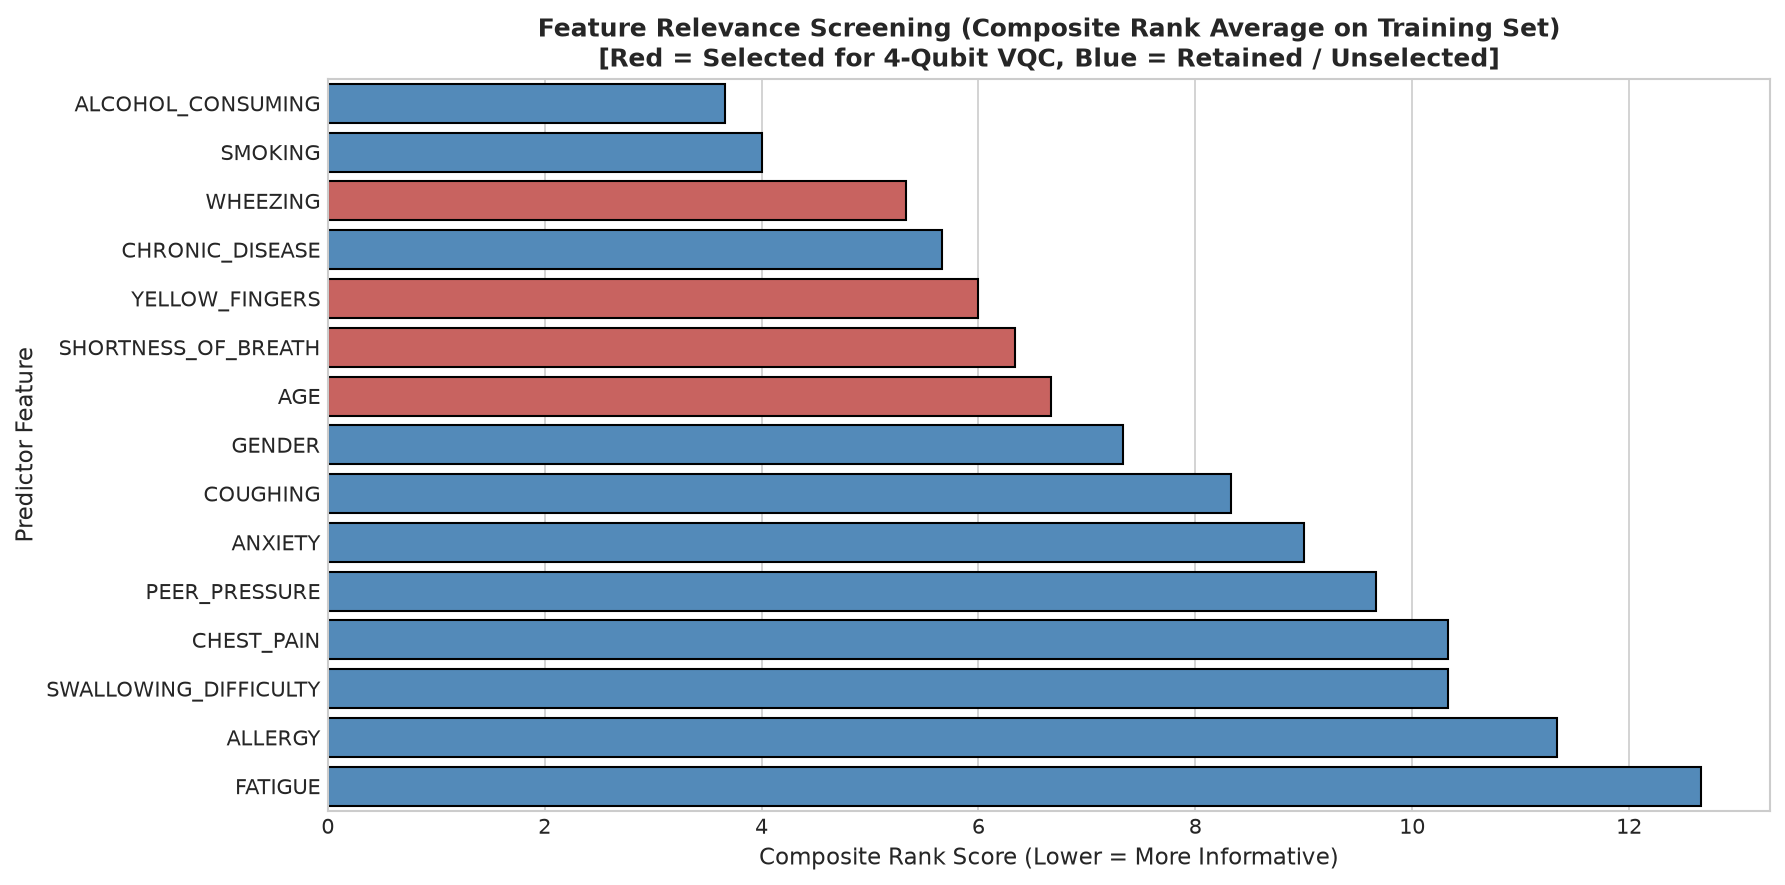

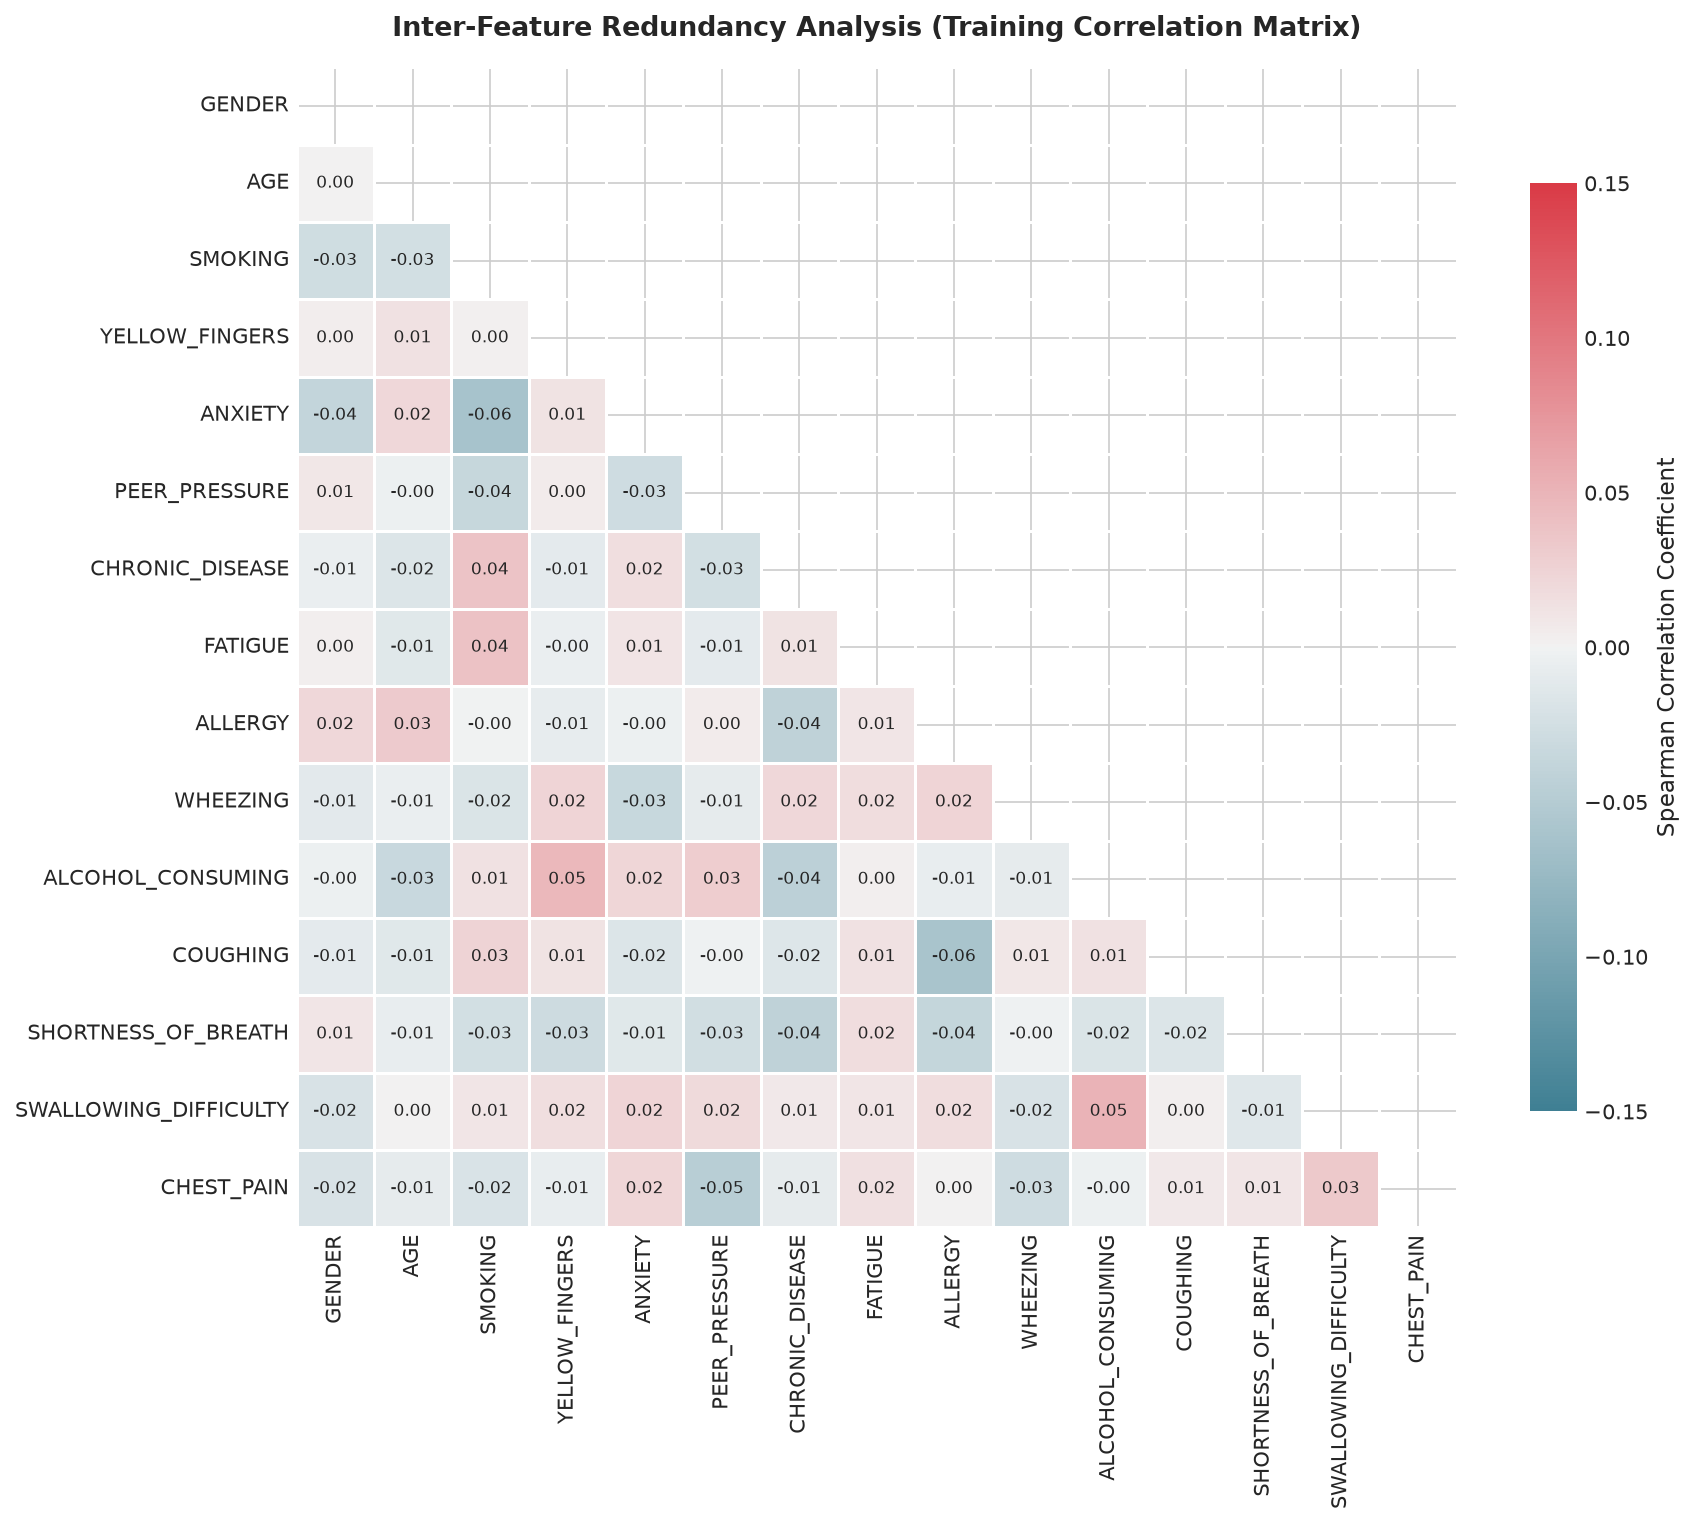

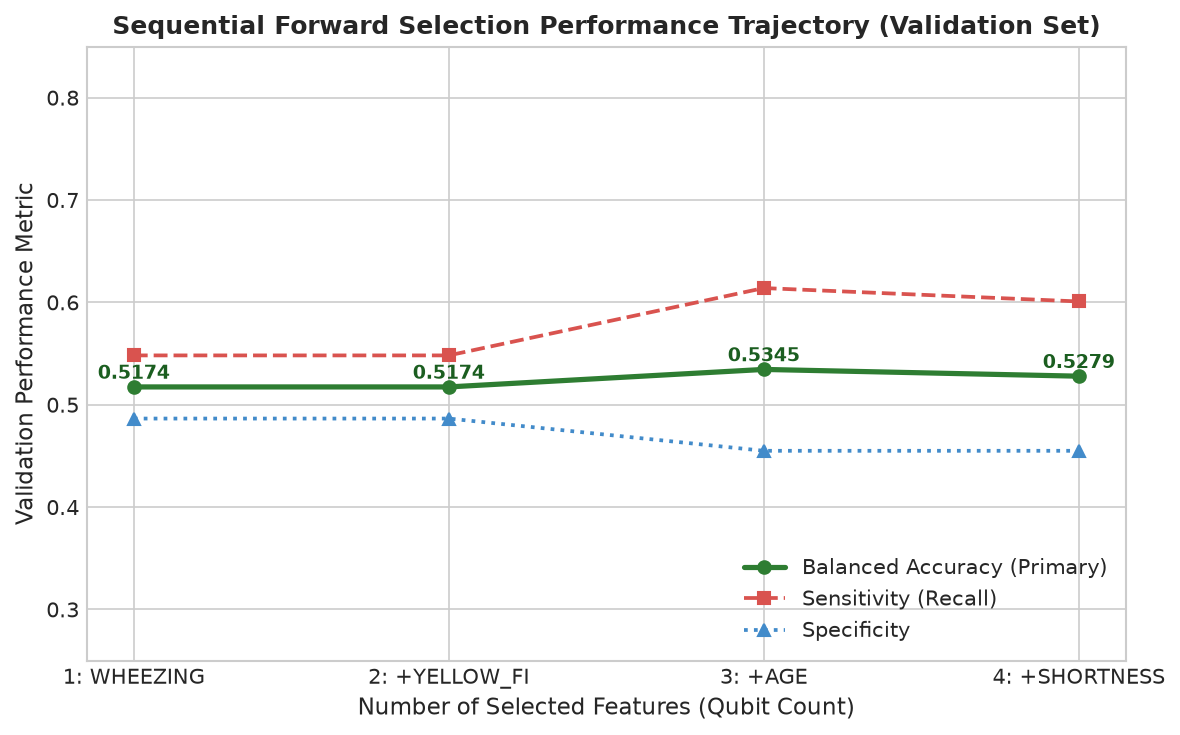

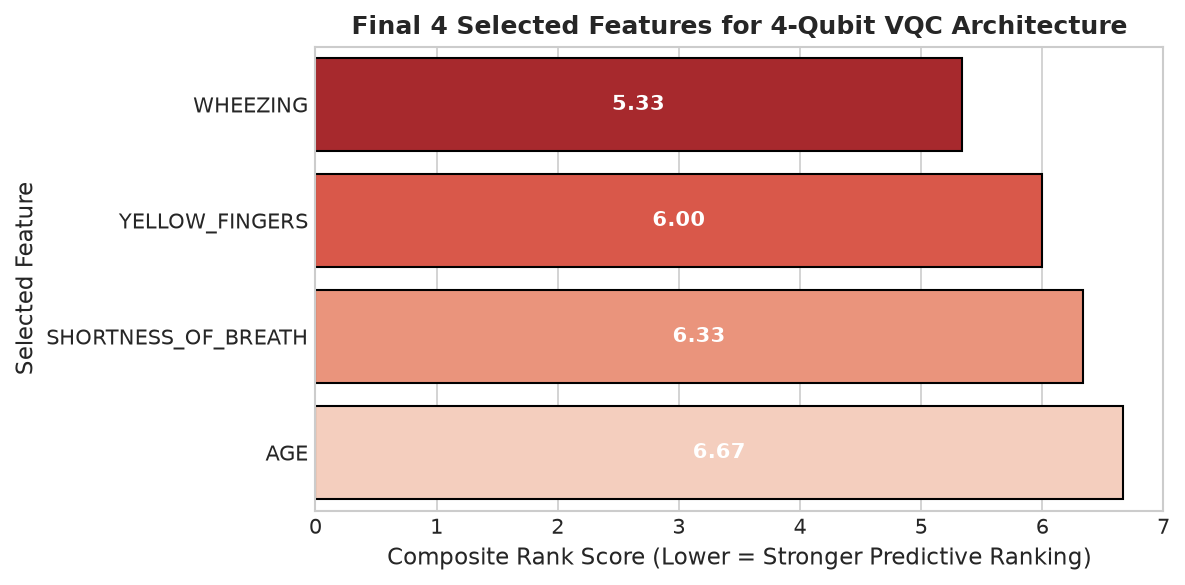

All 4 Feature Selection Visualizations saved successfully to outputs/feature_selection/figures/.


In [10]:
# ==============================================================================
# PART 11: FEATURE SELECTION VISUALIZATIONS GENERATION
# ==============================================================================

# 1. Feature Relevance Ranking Plot
fig, ax = plt.subplots(figsize=(12, 6))
plot_ranking_df = relevance_df.sort_values(by="Composite_Score", ascending=True)
colors = ["#d9534f" if f in selected_features else "#428bca" for f in plot_ranking_df["Feature"]]

sns.barplot(x="Composite_Score", y="Feature", data=plot_ranking_df, palette=colors, ax=ax, edgecolor="black")
ax.set_title("Feature Relevance Screening (Composite Rank Average on Training Set)\n[Red = Selected for 4-Qubit VQC, Blue = Retained / Unselected]", fontsize=12)
ax.set_xlabel("Composite Rank Score (Lower = More Informative)", fontsize=11)
ax.set_ylabel("Predictor Feature", fontsize=11)
plt.tight_layout()
fig1_path = FIGURES_DIR / "01_feature_relevance_ranking.png"
plt.savefig(fig1_path, dpi=300, bbox_inches='tight')
plt.show()

# 2. Feature Redundancy Heatmap
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap=cmap,
    vmax=0.15,
    vmin=-0.15,
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .8, "label": "Spearman Correlation Coefficient"},
    annot_kws={"size": 8},
    ax=ax
)
ax.set_title("Inter-Feature Redundancy Analysis (Training Correlation Matrix)", fontsize=13, pad=15)
plt.tight_layout()
fig2_path = FIGURES_DIR / "02_feature_redundancy_heatmap.png"
plt.savefig(fig2_path, dpi=300, bbox_inches='tight')
plt.show()

# 3. Sequential-Selection Performance Plot
fig, ax = plt.subplots(figsize=(8, 5))
steps = feature_count_df["Step"]
b_accs = feature_count_df["Balanced accuracy"]
sens = feature_count_df["Sensitivity"]
specs = feature_count_df["Specificity"]

ax.plot(steps, b_accs, marker="o", linewidth=2.5, color="#2e7d32", label="Balanced Accuracy (Primary)")
ax.plot(steps, sens, marker="s", linestyle="--", linewidth=1.8, color="#d9534f", label="Sensitivity (Recall)")
ax.plot(steps, specs, marker="^", linestyle=":", linewidth=1.8, color="#428bca", label="Specificity")

for s, b in zip(steps, b_accs):
    ax.annotate(f"{b:.4f}", (s, b + 0.008), ha='center', fontsize=9, fontweight='bold', color="#1b5e20")

ax.set_title("Sequential Forward Selection Performance Trajectory (Validation Set)", fontsize=12)
ax.set_xlabel("Number of Selected Features (Qubit Count)", fontsize=11)
ax.set_ylabel("Validation Performance Metric", fontsize=11)
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels([f"1: {selected_features[0]}", f"2: +{selected_features[1][:9]}", f"3: +{selected_features[2]}", f"4: +{selected_features[3][:9]}"])
ax.set_ylim(0.25, 0.85)
ax.legend(loc="lower right")
plt.tight_layout()
fig3_path = FIGURES_DIR / "03_sequential_selection_performance.png"
plt.savefig(fig3_path, dpi=300, bbox_inches='tight')
plt.show()

# 4. Final 4-Feature Ranking Plot
fig, ax = plt.subplots(figsize=(8, 4))
final_4_df = relevance_df[relevance_df["Feature"].isin(selected_features)].copy()
final_4_df = final_4_df.sort_values(by="Composite_Score")

sns.barplot(x="Composite_Score", y="Feature", data=final_4_df, palette="Reds_r", ax=ax, edgecolor="black")
ax.set_title("Final 4 Selected Features for 4-Qubit VQC Architecture", fontsize=12)
ax.set_xlabel("Composite Rank Score (Lower = Stronger Predictive Ranking)", fontsize=11)
ax.set_ylabel("Selected Feature", fontsize=11)
for p in ax.patches:
    w = p.get_width()
    ax.annotate(f"{w:.2f}", (w / 2., p.get_y() + p.get_height() / 2.),
                ha='center', va='center', fontsize=10, color='white', fontweight='bold')
plt.tight_layout()
fig4_path = FIGURES_DIR / "04_final_4_feature_ranking.png"
plt.savefig(fig4_path, dpi=300, bbox_inches='tight')
plt.show()

print("All 4 Feature Selection Visualizations saved successfully to outputs/feature_selection/figures/.")


---
## Part 12 — Final Feature-Selection Validation Summary

We summarize the validation metrics and performance progression across the 4 selected features.


In [11]:
# ==============================================================================
# PART 12: FEATURE SELECTION RESULTS SUMMARY
# ==============================================================================

best_val_result = step_progress_records[-1]

print("================================================================================")
print(" FINAL 4-FEATURE SELECTION VALIDATION PERFORMANCE")
print("================================================================================")
for metric, val in best_val_result.items():
    if isinstance(val, (int, float)):
        print(f"  {metric:<25}: {val:.4f}")
    else:
        print(f"  {metric:<25}: {val}")
print("================================================================================")


 FINAL 4-FEATURE SELECTION VALIDATION PERFORMANCE
  Step                     : 4.0000
  Selected Feature         : SHORTNESS_OF_BREATH
  Cumulative Feature Set   : ['WHEEZING', 'YELLOW_FINGERS', 'AGE', 'SHORTNESS_OF_BREATH']
  Accuracy                 : 0.5289
  Sensitivity              : 0.6009
  Specificity              : 0.4550
  Precision                : 0.5310
  F1-score                 : 0.5638
  Balanced accuracy        : 0.5279
  ROC-AUC                  : 0.5252


---
## Part 13 — Final Output for VQC Architecture

We create the reduced 4-feature datasets for subsequent quantum circuit modeling:
* `X_train_4`: 4-feature subset of `X_train`
* `X_validation_4`: 4-feature subset of `X_validation`
* `X_test_4`: 4-feature subset of `X_test`

> **Critical Testing Rule**: The test features `X_test_4` are projected into the selected 4-feature space, **while test labels (`y_test`) remain completely untouched and unobserved** until the final evaluation notebook.


In [12]:
# ==============================================================================
# PART 13: EXPORT 4-FEATURE SUBSETS FOR VQC (X_train_4, X_validation_4, X_test_4)
# ==============================================================================

# Extract exactly the 4 selected features
X_train_4 = X_train[selected_features].copy()
X_validation_4 = X_validation[selected_features].copy()
X_test_4 = X_test[selected_features].copy()

# Save 4-feature datasets
X_train_4.to_csv(ARTIFACTS_DIR / "X_train_4.csv", index=False)
X_validation_4.to_csv(ARTIFACTS_DIR / "X_validation_4.csv", index=False)
X_test_4.to_csv(ARTIFACTS_DIR / "X_test_4.csv", index=False)

print("================================================================================")
print(" 4-FEATURE QUANTUM DATASET ARTIFACTS EXPORTED")
print("================================================================================")
print(f"X_train_4 Shape:      {X_train_4.shape} (Saved: {ARTIFACTS_DIR / 'X_train_4.csv'})")
print(f"X_validation_4 Shape: {X_validation_4.shape} (Saved: {ARTIFACTS_DIR / 'X_validation_4.csv'})")
print(f"X_test_4 Shape:       {X_test_4.shape} (Saved: {ARTIFACTS_DIR / 'X_test_4.csv'})")
print(f"Selected 4 Features:  {list(X_train_4.columns)}")
print("Test labels:          REMAIN UNTOUCHED IN COLD STORAGE")
print("================================================================================\n")
display(X_train_4.head(3))


 4-FEATURE QUANTUM DATASET ARTIFACTS EXPORTED
X_train_4 Shape:      (2098, 4) (Saved: /home/logith-p/Desktop/hybrid-qml-disease-detection/artifacts/feature_selection/X_train_4.csv)
X_validation_4 Shape: (450, 4) (Saved: /home/logith-p/Desktop/hybrid-qml-disease-detection/artifacts/feature_selection/X_validation_4.csv)
X_test_4 Shape:       (450, 4) (Saved: /home/logith-p/Desktop/hybrid-qml-disease-detection/artifacts/feature_selection/X_test_4.csv)
Selected 4 Features:  ['WHEEZING', 'YELLOW_FINGERS', 'AGE', 'SHORTNESS_OF_BREATH']
Test labels:          REMAIN UNTOUCHED IN COLD STORAGE



,WHEEZING,YELLOW_FINGERS,AGE,SHORTNESS_OF_BREATH
0,1.0,0.0,0.48,0.0
1,1.0,1.0,0.00,0.0
2,0.0,0.0,0.82,1.0


---
## Final Notebook Output

We print the formal sign-off block summarizing original feature counts, candidate counts, final 4 selected features, selection criterion, validation performance, and pipeline readiness.


In [13]:
# ==============================================================================
# FINAL CELL: EXECUTIVE SUMMARY & PIPELINE SIGN-OFF
# ==============================================================================

final_val_perf = best_val_result['Balanced accuracy']

print(f"""========================================
FEATURE SELECTION COMPLETE
========================================

Original feature count:
{len(feature_names)}

Candidate feature count:
{len(shortlisted_features)}

Final feature count: 4

Selected features:
1. {selected_features[0]}
2. {selected_features[1]}
3. {selected_features[2]}
4. {selected_features[3]}

Selection criterion:
Balanced accuracy (Validation Set)

Validation performance:
{final_val_perf:.4f}

Test set used during selection:
NO

Ready for 4-qubit VQC:
YES
========================================""")


FEATURE SELECTION COMPLETE

Original feature count:
15

Candidate feature count:
8

Final feature count: 4

Selected features:
1. WHEEZING
2. YELLOW_FINGERS
3. AGE
4. SHORTNESS_OF_BREATH

Selection criterion:
Balanced accuracy (Validation Set)

Validation performance:
0.5279

Test set used during selection:
NO

Ready for 4-qubit VQC:
YES
